In [1]:
import torch
print(torch.__version__)

2.11.0+cpu


In [15]:
from sklearn.datasets import load_breast_cancer

In [16]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y

)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [25]:
import torch.nn as nn

def train_model(optimizer_name, learning_rate = 0.01, momentum = 0.0):
    model = nn.Sequential(
        nn.Linear(30, 1)
    )

    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr = learning_rate
        )

    elif optimizer_name == "momentum":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr = learning_rate,
            momentum= momentum
        )

    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    losses = []

    for epoch in range(100):

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs.squeeze(), y_train)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return model, losses

In [26]:
sgd_model, sgd_losses = train_model("sgd")

print(sgd_losses[:5])
print(sgd_losses[-5:])

[0.8660405874252319, 0.8371551632881165, 0.809859037399292, 0.7840970754623413, 0.7598085999488831]
[0.2639200985431671, 0.26263654232025146, 0.2613721191883087, 0.26012638211250305, 0.2588987946510315]


In [27]:
momentum_model, momentum_losses = train_model('momentum')

print(momentum_losses[:5])
print(momentum_losses[-5:])

[0.8443930745124817, 0.8217320442199707, 0.8001874685287476, 0.7797112464904785, 0.7602552771568298]
[0.28739306330680847, 0.28593388199806213, 0.28449565172195435, 0.28307783603668213, 0.28167998790740967]


In [28]:
adam_model, adam_losses = train_model('adam')

print(adam_losses[:5])
print(adam_losses[-5:])

[0.5751090049743652, 0.5195643901824951, 0.4712495505809784, 0.4294494092464447, 0.3933681547641754]
[0.08362357318401337, 0.083318330347538, 0.08301794528961182, 0.08272228389978409, 0.08243126422166824]


In [32]:
def evaluate_model(model):

    with torch.no_grad():
        outputs = model(X_test)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        accuracy = (predictions.squeeze() == y_test).float().mean()

    return accuracy.item()

In [33]:
print("SGD:", evaluate_model(sgd_model))
print("Momentum:", evaluate_model(momentum_model))
print("Adam:", evaluate_model(adam_model))

SGD: 0.9122806787490845
Momentum: 0.8947368264198303
Adam: 0.9649122953414917


| Optimizer | Final Train Loss | Test Accuracy |
| --------- | ---------------- | ------------- |
| SGD       | 0.258898         | 0.912280      |
| Momentum  | 0.281679         | 0.894736      |
| Adam      | 0.08243          | 0.964912      |


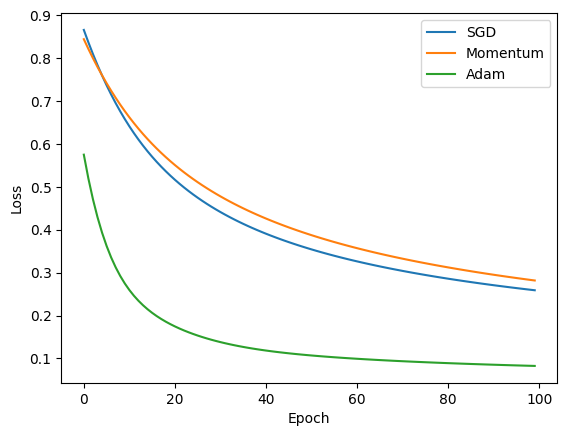

In [34]:
import matplotlib.pyplot as plt

plt.plot(sgd_losses, label="SGD")
plt.plot(momentum_losses, label="Momentum")
plt.plot(adam_losses, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [35]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [36]:
def batch_train_model(optimizer_name, learnin_rate=0.01, momentum=0.01):
 
    model = nn.Sequential(nn.Linear(30, 1))

    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr = learnin_rate
        )

    elif optimizer_name == "momentum":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr = learnin_rate,
            momentum= momentum
        )

    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr = learnin_rate
        )

    
    losses = []

    for epoch in range(100):

        epoch_loss = 0

        for batch_X, batch_y in train_loader:

            optimizer.zero_grad()

            outputs = model(batch_X)

            loss = criterion(outputs.squeeze(), batch_y)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

    return model, losses

In [37]:
batch_sgd_model, batch_sgd_losses = batch_train_model("sgd")

batch_momentum_model, batch_momentum_losses = batch_train_model(
    "momentum",
    momentum=0.9
)

batch_adam_model, batch_adam_losses = batch_train_model("adam")

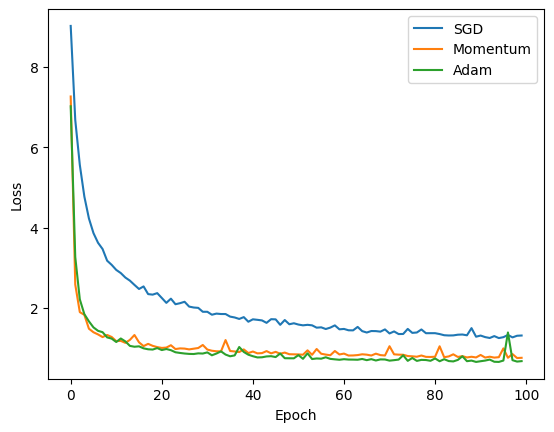

In [47]:
plt.plot(batch_sgd_losses, label="SGD")
plt.plot(batch_momentum_losses, label="Momentum")
plt.plot(batch_adam_losses, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [43]:
print("SGD Loss:",batch_sgd_losses[-1])
print("Momentum Loss:",batch_momentum_losses[-1])
print("Adam Loss:",batch_adam_losses[-1])

SGD Loss: 1.3169605731964111
Momentum Loss: 0.7617928218096495
Adam Loss: 0.6791975479573011


In [39]:
print("SGD:", evaluate_model(batch_sgd_model))
print("Momentum:", evaluate_model(batch_momentum_model))
print("Adam:", evaluate_model(batch_adam_model))

SGD: 0.9736841917037964
Momentum: 0.9649122953414917
Adam: 0.9824561476707458


Did lower loss translate to much better accuracy?
    No lower loss did not translate to better accuracy, accuracy across optimizers is more or less the same. I would reason it has to do with samples being accurately placed in the right classes but confidence across optimizers vary
Which optimizer converged fastest?
    Adam converged fast and smooth, momentum converged fast but not as smooth and SGD was slower to converge and not as smooth
Which optimizer appeared most stable?
    SGD appeared most stable. Though Adam and momentum lie in lower loss region, there are lot of fluctuations there
Why might SGD still generalize competitively despite noisier optimization?
    SGD's noisy gradients bias it toward flatter minima, which allows for better generalization
What role did batching play in stochasticity?
    Batching allowed the optimizer to see different parts of data a time which introduced gradients not based on the whole data. These gradients tend to be noisy and stochastic